## Rolling Statistics with Financial Data

In [21]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

In [2]:
stocks = dict(
    AAPL = 'Apple Stock',
    AMZN = 'Amazon Stock',
    CNY = 'CNY/USD Exchange Rate',
    GDX = 'Gold Price',
    GLD = 'SPDR Gold Trust',
    GS = 'Goldman Sachs Stock',
    INTC = 'Intel Stock',
    MSFT = 'Microsoft Stock',
    SPY = 'S&P 500'
)

In [5]:
stocks.keys()

dict_keys(['AAPL', 'AMZN', 'CNY', 'GDX', 'GLD', 'GS', 'INTC', 'MSFT', 'SPY'])

In [7]:
df = yf.download(list(stocks.keys()), period='max')

/tmp/ipykernel_5605/2208765711.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(list(stocks.keys()), period='max')
[*********************100%***********************]  9 of 9 completed


In [9]:
df = df['Open'].dropna()

In [10]:
df

Ticker,AAPL,AMZN,CNY,GDX,GLD,GS,INTC,MSFT,SPY
Date,,,,,,,,,
2009-01-02,2.573223,2.567500,39.542000,29.000340,85.930000,62.315044,9.197631,14.228545,66.138407
2009-01-05,2.791653,2.786500,39.590000,27.658935,83.620003,63.642661,9.435553,14.716678,67.739909
2009-01-06,2.874951,2.727500,39.610001,27.546433,83.370003,66.787366,9.448077,15.117374,68.478529
2009-01-07,2.750905,2.814500,39.709999,28.005107,84.559998,64.458512,9.260244,14.709390,67.279196
2009-01-08,2.709555,2.749500,39.450001,26.732932,84.400002,61.944266,9.047363,14.301403,65.933648
...,...,...,...,...,...,...,...,...,...
2020-04-03,58.666777,95.557503,44.250000,23.353198,152.229996,129.483284,47.734572,147.330531,230.509020
2020-04-06,60.623942,96.800003,44.250000,24.142158,154.160004,134.924714,50.198861,152.289024,237.017226
2020-04-07,65.432286,100.855499,44.250000,24.699073,155.330002,144.063175,53.132965,161.094638,252.065175


In [11]:
symbol = 'AMZN'
window = 20
df['min'] = df[symbol].rolling(window=window).min()
df['mean'] = df[symbol].rolling(window=window).mean()
df['std'] = df[symbol].rolling(window=window).std()
df['median'] = df[symbol].rolling(window=window).median()
df['max'] = df[symbol].rolling(window=window).max()
df['ewma'] = df[symbol].ewm(halflife=0.5, min_periods=window).mean()

In [14]:
df = df.dropna()
df.head()

Ticker,AAPL,AMZN,CNY,GDX,GLD,GS,INTC,MSFT,SPY,min,mean,std,median,max,ewma
Date,,,,,,,,,,,,,,,
2009-01-30,2.774575,2.8680,39.689999,30.757155,90.699997,61.996162,8.421248,12.924447,62.145526,2.428,2.600675,0.148325,2.54275,2.8680,2.774538
2009-02-02,2.669704,2.9285,39.779999,28.861877,89.879997,58.428743,8.026795,12.407179,59.651793,2.428,2.618725,0.165093,2.54275,2.9285,2.890010
2009-02-03,2.754199,3.0435,40.580002,28.905147,89.339996,62.522759,8.558997,13.004584,60.770680,2.428,2.631575,0.187341,2.54275,3.0435,3.005127
2009-02-04,2.793152,3.1690,40.250000,29.164777,88.889999,62.077735,8.716747,13.507283,61.648254,2.428,2.653650,0.222038,2.54275,3.1690,3.128032
2009-02-05,2.779668,3.0575,40.299999,30.203281,90.750000,64.354690,8.634514,13.485426,60.478170,2.428,2.665800,0.237419,2.54275,3.1690,3.075133


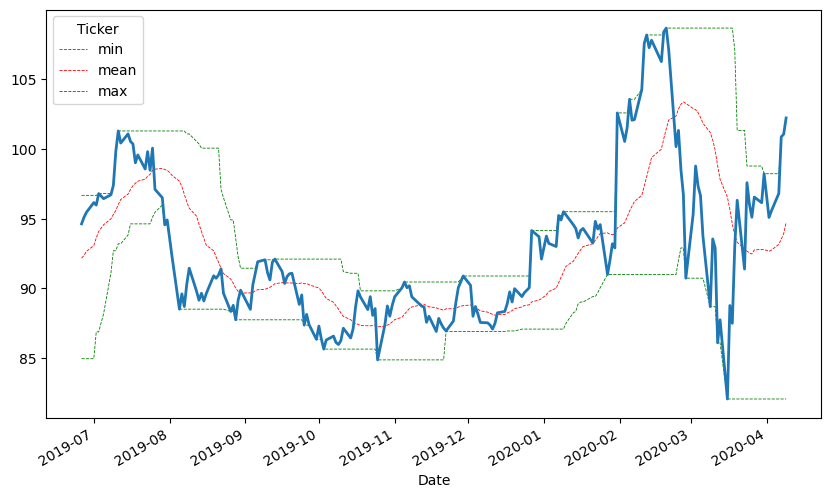

In [15]:
ax = df[['min', 'mean', 'max']].iloc[-200:].plot(
    figsize=(10,6),
    style=['g--', 'r--', 'g--'],
    lw=0.6
)
df[symbol].iloc[-200:].plot(ax=ax, lw=2.0);

### Technical Analysis

- Simple Moving Average

In [16]:
df['SMA1'] = df[symbol].rolling(window=42).mean()
df['SMA2'] = df[symbol].rolling(window=252).mean()

/tmp/ipykernel_5605/2112803287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SMA1'] = df[symbol].rolling(window=42).mean()
/tmp/ipykernel_5605/2112803287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SMA2'] = df[symbol].rolling(window=252).mean()


In [17]:
df

Ticker,AAPL,AMZN,CNY,GDX,GLD,GS,INTC,MSFT,SPY,min,mean,std,median,max,ewma,SMA1,SMA2
Date,,,,,,,,,,,,,,,,,
2009-01-30,2.774575,2.868000,39.689999,30.757155,90.699997,61.996162,8.421248,12.924447,62.145526,2.4280,2.600675,0.148325,2.542750,2.868000,2.774538,NaN,NaN
2009-02-02,2.669704,2.928500,39.779999,28.861877,89.879997,58.428743,8.026795,12.407179,59.651793,2.4280,2.618725,0.165093,2.542750,2.928500,2.890010,NaN,NaN
2009-02-03,2.754199,3.043500,40.580002,28.905147,89.339996,62.522759,8.558997,13.004584,60.770680,2.4280,2.631575,0.187341,2.542750,3.043500,3.005127,NaN,NaN
2009-02-04,2.793152,3.169000,40.250000,29.164777,88.889999,62.077735,8.716747,13.507283,61.648254,2.4280,2.653650,0.222038,2.542750,3.169000,3.128032,NaN,NaN
2009-02-05,2.779668,3.057500,40.299999,30.203281,90.750000,64.354690,8.634514,13.485426,60.478170,2.4280,2.665800,0.237419,2.542750,3.169000,3.075133,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-03,58.666777,95.557503,44.250000,23.353198,152.229996,129.483284,47.734572,147.330531,230.509020,82.0755,92.746500,4.485002,94.313000,98.217499,95.553040,97.554488,92.818720
2020-04-06,60.623942,96.800003,44.250000,24.142158,154.160004,134.924714,50.198861,152.289024,237.017226,82.0755,93.151850,4.465679,95.091000,98.217499,96.488262,97.393750,92.839950
2020-04-07,65.432286,100.855499,44.250000,24.699073,155.330002,144.063175,53.132965,161.094638,252.065175,82.0755,93.517425,4.787170,95.328751,100.855499,99.763690,97.365286,92.876435


In [18]:
df[[symbol, 'SMA1', 'SMA2']].tail()

Ticker,AMZN,SMA1,SMA2
Date,,,
2020-04-03,95.557503,97.554488,92.818720
2020-04-06,96.800003,97.393750,92.839950
2020-04-07,100.855499,97.365286,92.876435
2020-04-08,101.050003,97.340298,92.911258
2020-04-09,102.214996,97.291833,92.951595


In [19]:
df.dropna(inplace=True)

/tmp/ipykernel_5605/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [22]:
# long position 1; short 2
df['positions'] = np.where(df['SMA1'] > df['SMA2'], 1, -1)

/tmp/ipykernel_5605/978789811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] = np.where(df['SMA1'] > df['SMA2'], 1, -1)


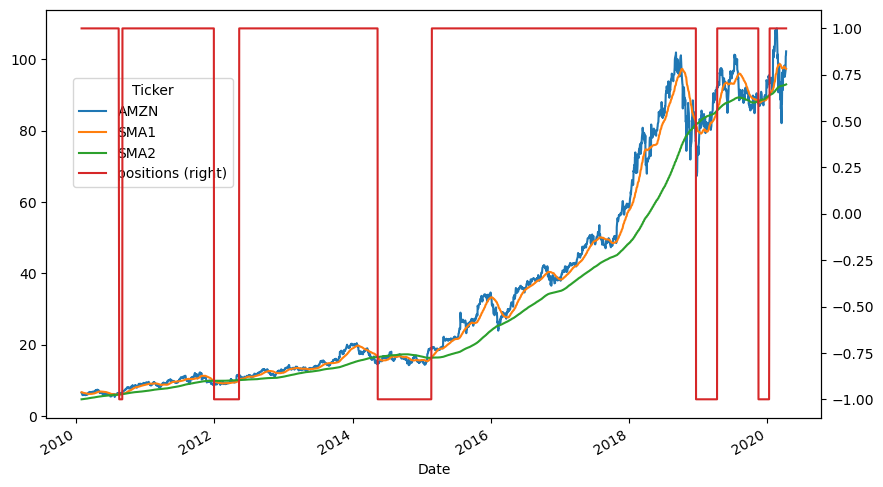

In [23]:
ax = df[[symbol, 'SMA1', 'SMA2', 'positions']].plot(figsize=(10, 6),
                                                   secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85));